# F_ephys_opto_examples.ipynb

## Purpose

Generates single-unit example raster + PSTH figures and raw traces for a opto tagging experiments.

## Manuscript figure panels

- Fig

## Prerequisites


Required input files:
- Per-session spike data

## Setup and Imports

Import required libraries for data processing, spike analysis, and visualization. This notebook uses custom utilities from the capsule for loading behavioral and electrophysiology data, as well as standard scientific Python packages for statistical analysis and plotting.

In [1]:
import sys
import os
from matplotlib.colors import LinearSegmentedColormap
# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
import ast
from pathlib import Path
import glob
import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb
from utils.ephys_functions import*
from utils.ccf_utils import ccf_pts_convert_to_mm, pir_to_lps, project_to_plane
from utils.combine_tools import apply_qc, to_str_intlike
from utils.capsule_migration import capsule_directories
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df
from ani_session_processing.antidromic_analysis_session import plot_opto_responses
import pickle
import scipy.stats as stats
import spikeinterface as si
import shutil
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score
import warnings
from scipy.stats import gaussian_kde
import trimesh
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from utils.ccf_utils import ccf_pts_convert_to_mm
from trimesh import load_mesh
from scipy.stats import pearsonr
import statsmodels.api as sm
from aind_ephys_utils import align
from aind_dynamic_foraging_data_utils.nwb_utils import load_nwb_from_filename
import k3d
from ani_session_processing.opto_id_tt import opto_id_tt
warnings.filterwarnings('ignore')
capsule_dirs = capsule_directories()

%matplotlib inline

In [2]:
target_folder = f'{capsule_dirs["manuscript_fig_dir"]}/F_ephys_opto_example_figs'
if not os.path.exists(target_folder):
    os.makedirs(target_folder)

# Example rasters and waveforms

In [ ]:
examples = [('behavior_ZS061_2021-04-16_17-08-59', 'TT4_SS_02', '10ms', 'FigureS13d_right'),
            ('behavior_ZS061_2021-03-30_16-57-26', 'TT3_SS_01', '20ms', 'FigureS13d_left')]

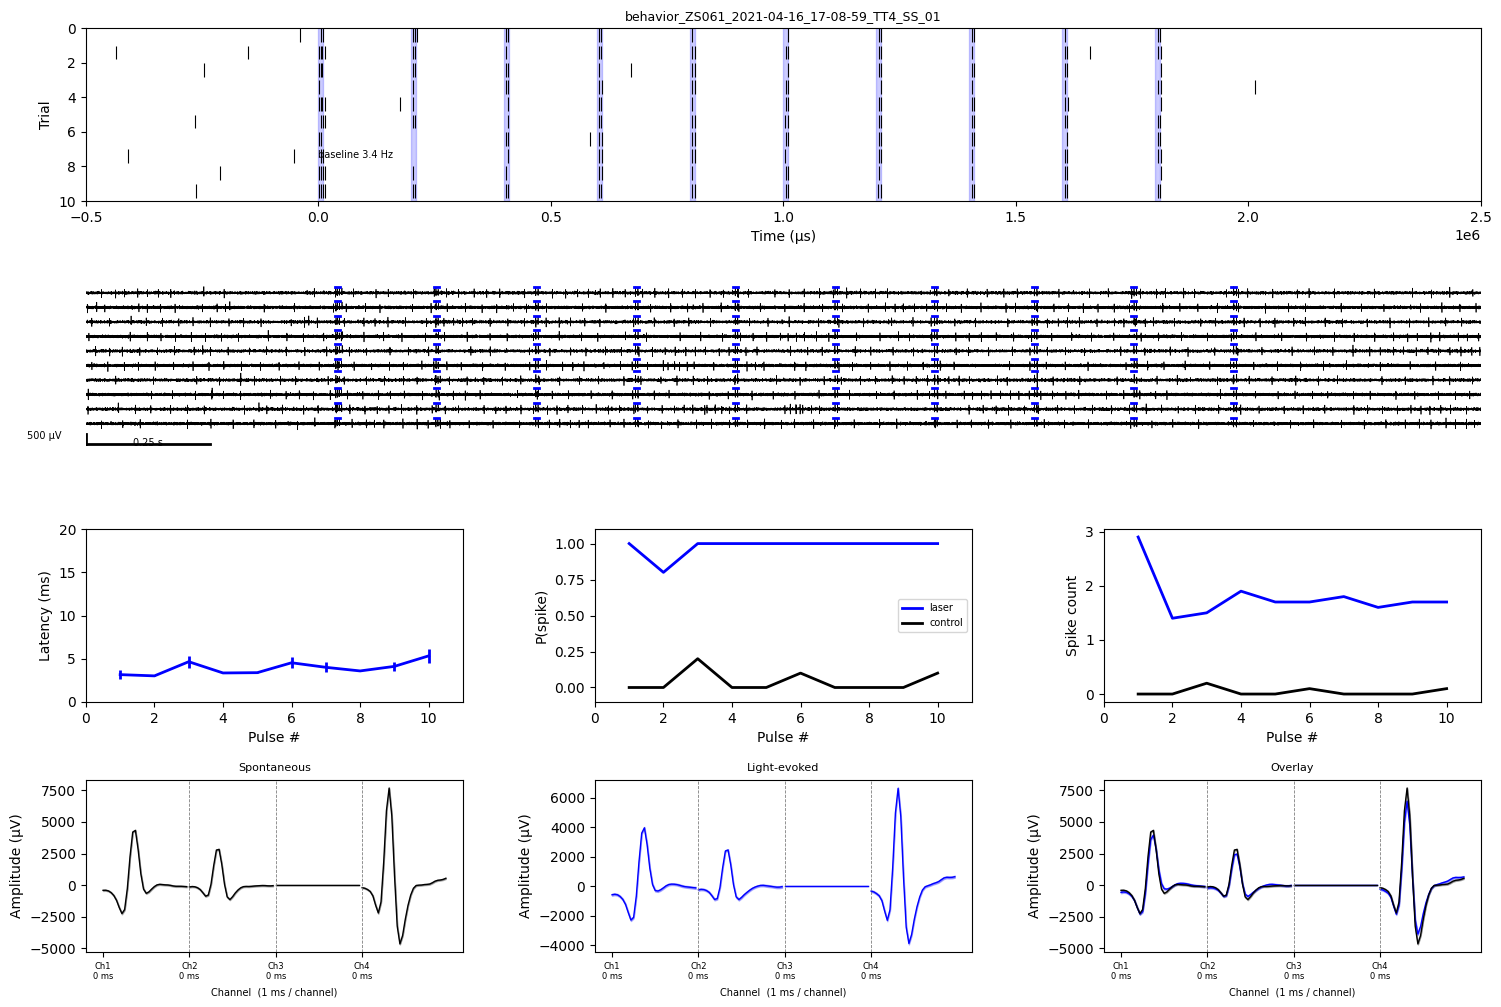

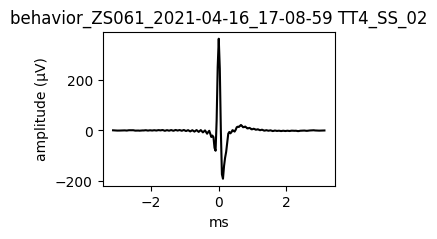

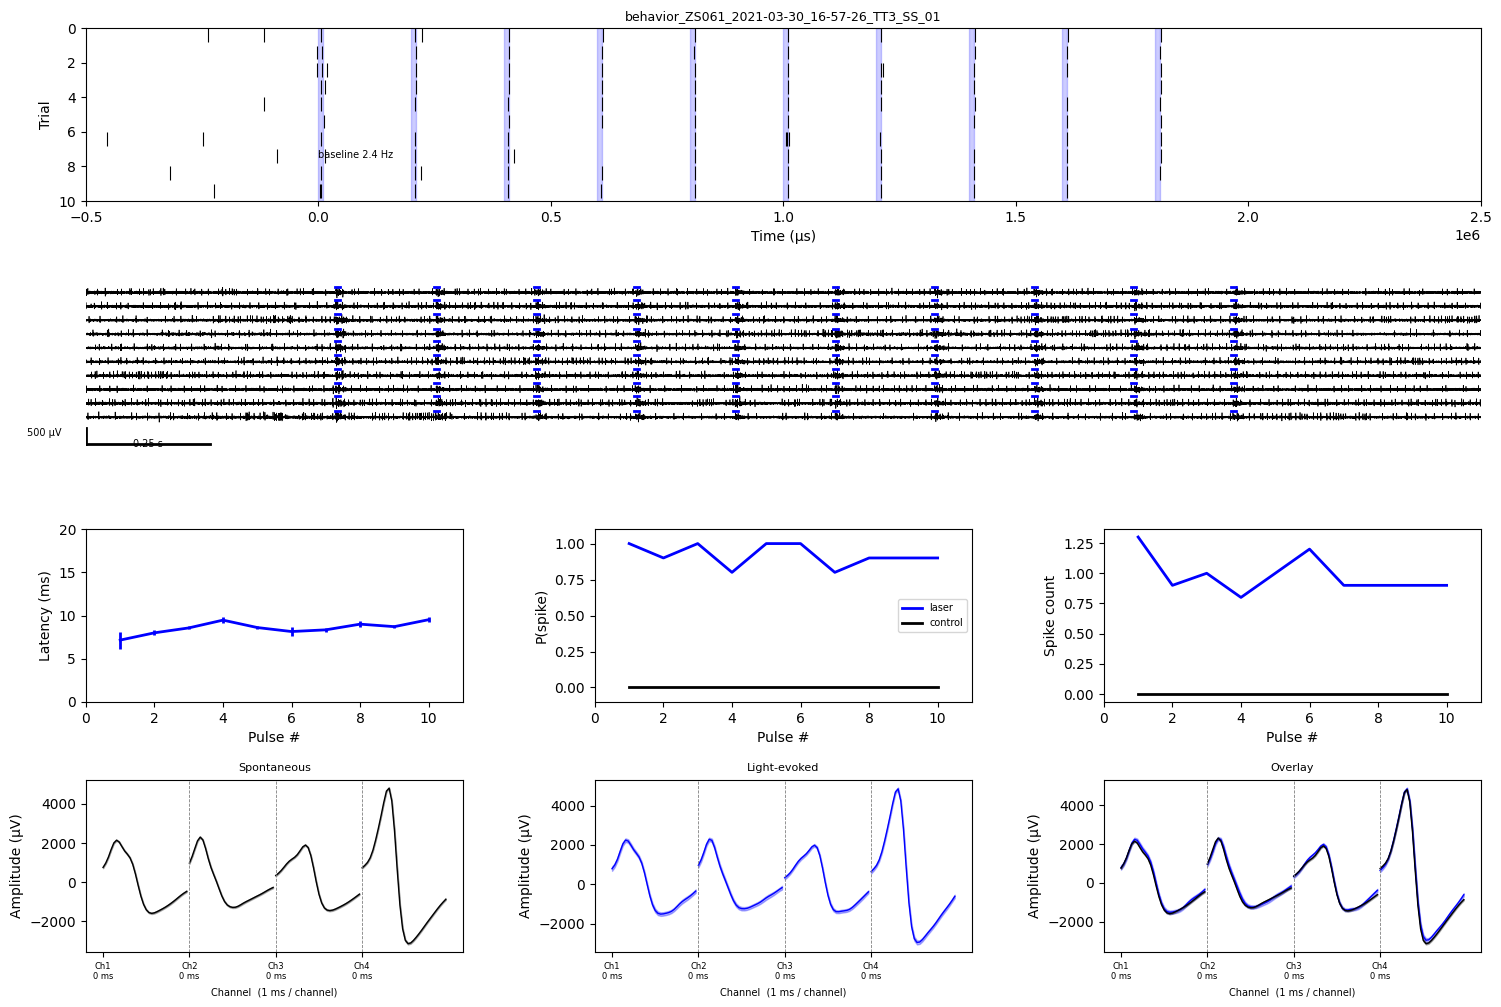

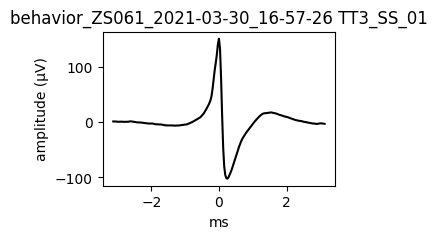

In [59]:
for example in examples:
    session_dir = session_dirs(example[0])
    nwb_ori = load_nwb_from_filename(session_dir['fp_nwb_dir'])
    unit_tbl = nwb_ori.units.to_dataframe()
    unit_row = unit_tbl[unit_tbl['unit_id'] == example[1]].iloc[0]
    opto_path = os.path.join(session_dir['raw_dir'], 'ecephys', 'neuralynx', 'opto', example[2])
    figs = opto_id_tt(opto_path, [unit_row['opto_unit']], session_label=example[0])
    # save figure
    ##FigureS13d_left##
    ##FigureS13d_right##
    save_panels(figs[0], target_folder, f"example_raster_opto-tagging+waveform_{example[0]}_{examples[1]}", [example[3]], exts=['svg'])

    # Build tidy raster CSV: one row per event (spike or laser pulse),
    # columns: event_type, train, relative_time_s
    from ani_session_processing.opto_id_tt import read_nev
    from pathlib import Path as _Path
    _opto_dir = _Path(opto_path)
    _n_pulses = 10
    _n_trains = 10
    _shutter_offset_ms = 0.8
    _pulse_width_ms = float(example[2].replace('ms', ''))
    _pw_us = _pulse_width_ms * 1000.0
    _t_before_us = 500_000.0
    _t_after_us  = 500_000.0

    _ts_ev, _ttl_ev = read_nev(str(_opto_dir / 'Events.nev'))
    _laser_raw_ttl = 1024
    _laser = 4
    _ttl_ev = _ttl_ev.copy()
    _ttl_ev[_ttl_ev == _laser_raw_ttl] = _laser
    _is_laser = (_ttl_ev == _laser).astype(int)
    _onset_mask = (_is_laser[:-1] == 0) & (_is_laser[1:] == 1)
    _laser_on_us = _ts_ev[:-1][_onset_mask] + _shutter_offset_ms * 1000.0
    _pulse_freq_hz = round(1e6 / np.min(np.diff(_laser_on_us)))
    _pulse_inds = np.arange(0, _n_pulses * _n_trains, _n_pulses)

    # load spike times for this unit
    _sorted_files = sorted(_opto_dir.glob('*TT*_SS*.txt'))
    _sf = [f for f in _sorted_files if unit_row['opto_unit'] in f.name][0]
    _spike_times = np.loadtxt(str(_sf)).ravel().astype(np.int64)

    rows = []
    for j in range(_n_trains):
        t0 = _laser_on_us[_pulse_inds[j]]
        t_last = _laser_on_us[_pulse_inds[j] + _n_pulses - 1]

        # laser pulses for this train
        for k in range(_n_pulses):
            pulse_t = _laser_on_us[_pulse_inds[j] + k]
            rows.append({'event_type': 'laser', 'train': j, 'pulse': k,
                         'relative_time_s': (pulse_t - t0) / 1e6})

        # spikes in the raster window for this train
        _win = (_spike_times > t0 - _t_before_us) & (_spike_times < t_last + _pw_us + _t_after_us)
        for sp_t in _spike_times[_win]:
            rows.append({'event_type': 'spike', 'train': j, 'pulse': np.nan,
                         'relative_time_s': (sp_t - t0) / 1e6})

    raster_df = pd.DataFrame(rows, columns=['event_type', 'train', 'pulse', 'relative_time_s'])
    save_panel_csv(raster_df, target_folder,
                   f"opto_raster_{example[0]}_{example[1]}", [example[3]])
    # load waveform data for this unit from nwb
    spont_wf = unit_row['peak_wf_aligned']
    fig = plt.figure(figsize=(3, 2))
    ax = fig.add_subplot(1, 1, 1)
    time = (np.arange(len(spont_wf)) - 100) / 32.0  # ms
    ax.plot(time, -spont_wf, color='black', label='spontaneous')
    
    ax.set_ylabel('amplitude (µV)')
    ax.set_title(f"{example[0]} {example[1]}")
    ax.set_xlabel('ms')
    # save fig
    save_panels(fig, target_folder, f"example_waveform_{example[0]}_{example[1]}", [example[3]], exts=['svg'])
    # save waveform data to CSV
    wf_df = pd.DataFrame({'time_ms': time, 'amplitude_uV': spont_wf})
    save_panel_csv(wf_df, target_folder, f"waveform_{example[0]}_{example[1]}", [example[3]])



# Raw traces

In [4]:
examples = [('behavior_ZS062_2021-05-04_14-29-20', 'TT6_SS_01'),
            ('behavior_ZS062_2021-05-05_16-34-46', 'TT6_SS_01'),
            ('behavior_ZS062_2021-05-05_16-34-46', 'TT6_SS_02'),
            ('behavior_ZS062_2021-05-06_15-46-14', 'TT6_SS_01'),
            ('behavior_ZS062_2021-05-06_15-46-14', 'TT6_SS_02'),
            ('behavior_ZS062_2021-05-07_17-38-21', 'TT6_SS_01'),
            ('behavior_ZS062_2021-05-07_17-38-21', 'TT6_SS_03')]
sessions = ['behavior_ZS062_2021-05-04_14-29-20',
            'behavior_ZS062_2021-05-05_16-34-46',
            'behavior_ZS062_2021-05-06_15-46-14',
            'behavior_ZS062_2021-05-07_17-38-21']

In [13]:
# pull all opto-tagged neurons in example sessions on TT6
examples = []
for session in sessions:
    nwb_ori = load_nwb_from_filename(session_dirs(session)['fp_nwb_dir'])
    unit_tbl = nwb_ori.units.to_dataframe()
    unit_tbl_filtered = unit_tbl[
        unit_tbl['unit_id'].astype(str).str.startswith('TT6') &
        (unit_tbl['opto_pass'] == True)
    ]
    for _, row in unit_tbl_filtered.iterrows():
        examples.append((session, row['unit_id'], row['opto_unit']))

In [14]:
examples

[('behavior_ZS062_2021-05-04_14-29-20', 'TT6_SS_02', 'TT6_SS_02'),
 ('behavior_ZS062_2021-05-04_14-29-20', 'TT6_SS_03', 'TT6_SS_01'),
 ('behavior_ZS062_2021-05-05_16-34-46', 'TT6_SS_01', 'TT6_SS_01'),
 ('behavior_ZS062_2021-05-05_16-34-46', 'TT6_SS_02', 'TT6_SS_02'),
 ('behavior_ZS062_2021-05-06_15-46-14', 'TT6_SS_01', 'TT6_SS_02'),
 ('behavior_ZS062_2021-05-06_15-46-14', 'TT6_SS_02', 'TT6_SS_01'),
 ('behavior_ZS062_2021-05-07_17-38-21', 'TT6_SS_01', 'TT6_SS_01'),
 ('behavior_ZS062_2021-05-07_17-38-21', 'TT6_SS_02', 'TT6_SS_03')]